# Exploratory Data Analysis (EDA)

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# load data-set

# cleveland

In [16]:
# Load the dataset
df = pd.read_csv("data/processed/cleveland_clean.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# data analysis

In [17]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

Rows: 303, Columns: 14



In [18]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

In [19]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [20]:
total = len(df)
healthy_count = (df["target"] == 0).sum()
disease_count = (df["target"] == 1).sum()

healthy_pct = (healthy_count / total) * 100
disease_pct = (disease_count / total) * 100

print(f"Healthy %: {healthy_pct:.2f}%")
print(f"Heart Disease %: {disease_pct:.2f}%\n")

Healthy %: 54.13%
Heart Disease %: 45.87%



# visulivation 

C:\Users\Windows 11-Pro Edu\AppData\Local\Temp\ipykernel_2336\333541168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="Set2")


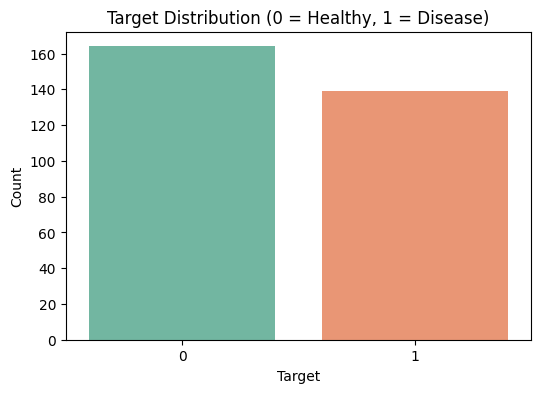

In [21]:
# Task: Target Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df, palette="Set2")
plt.title("Target Distribution (0 = Healthy, 1 = Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

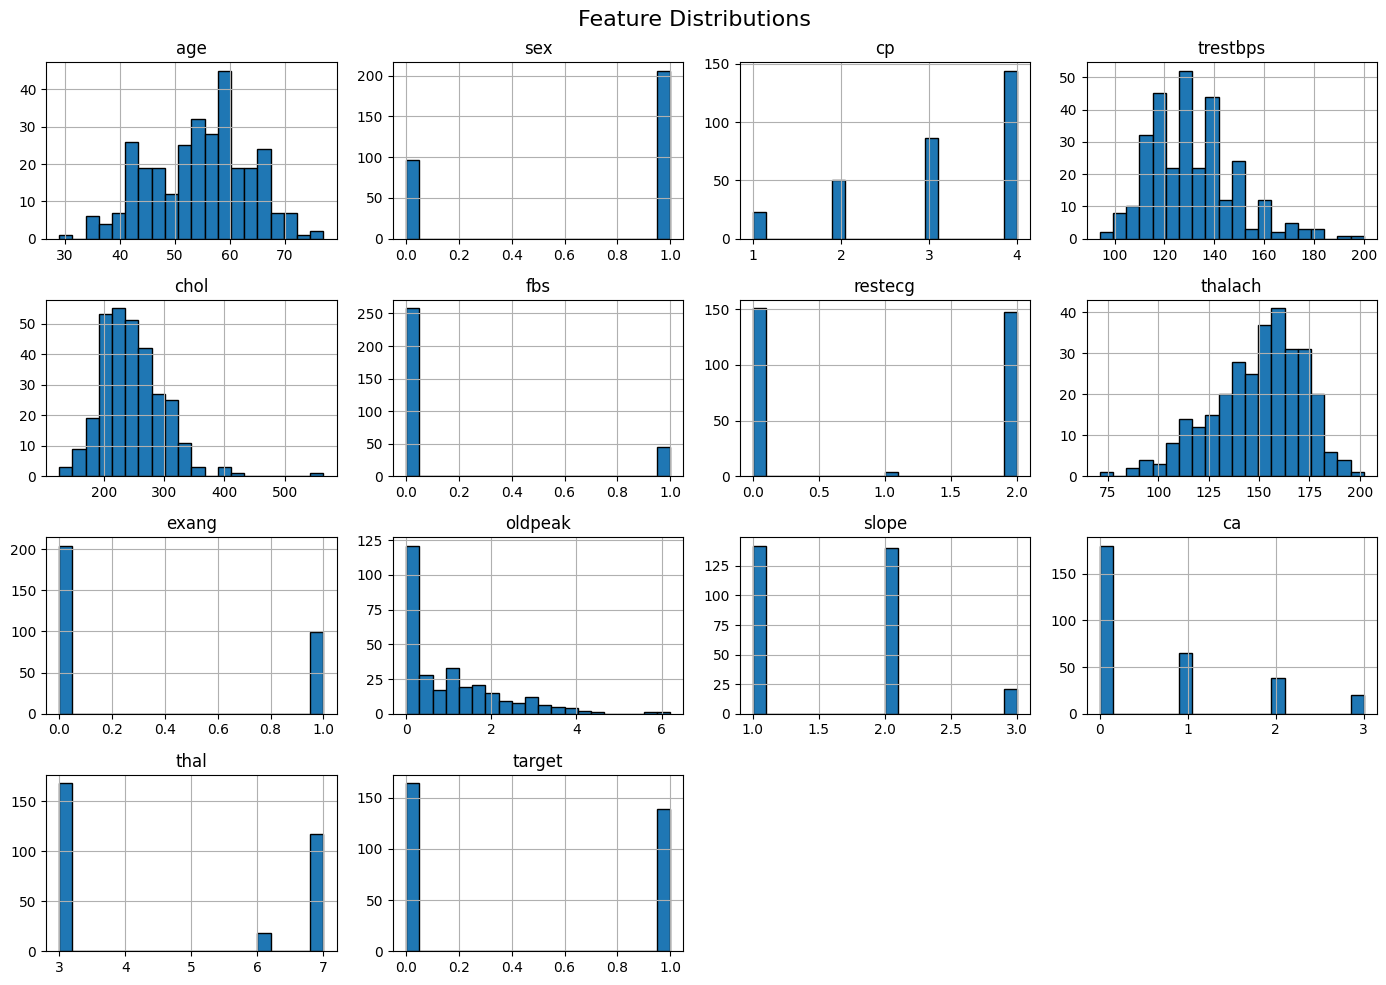

In [22]:
# Task: Feature Distributions (Histograms)
df.hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.365323,0.128303,0.223120
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.086048,0.380581,0.276816
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233117,0.262089,0.414446
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.097528,0.134424,0.150825
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.123726,0.018351,0.085164
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.140764,0.064625,0.025264
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.131749,0.024325,0.169202
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.265699,-0.274142,-0.417167
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145788,0.325240,0.431894
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.301067,0.342405,0.424510


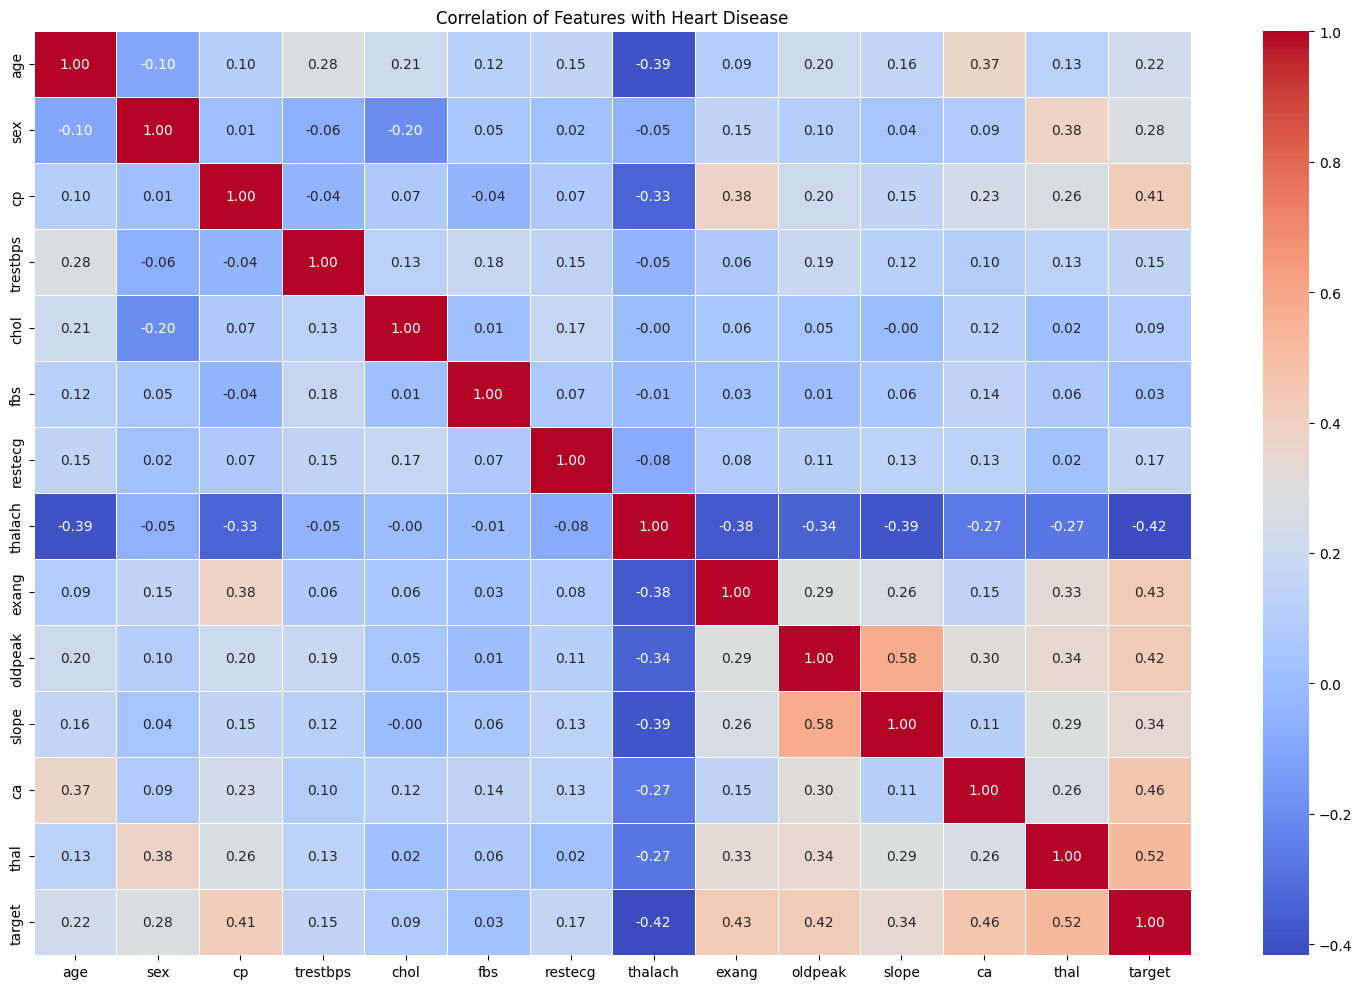

In [24]:
# 1. Set the figure size BEFORE creating the plot
plt.figure(figsize=(15, 10))

# 2. Use your correlation matrix (replace df.corr() if needed)
# annot=True shows the values, fmt=".2f" keeps them at 2 decimal places
# cmap='coolwarm' is a standard color palette for correlations
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Add titles and labels
plt.title('Correlation of Features with Heart Disease')

# 4. Display the plot
plt.tight_layout() # Ensures the labels aren't cut off
plt.show()
     

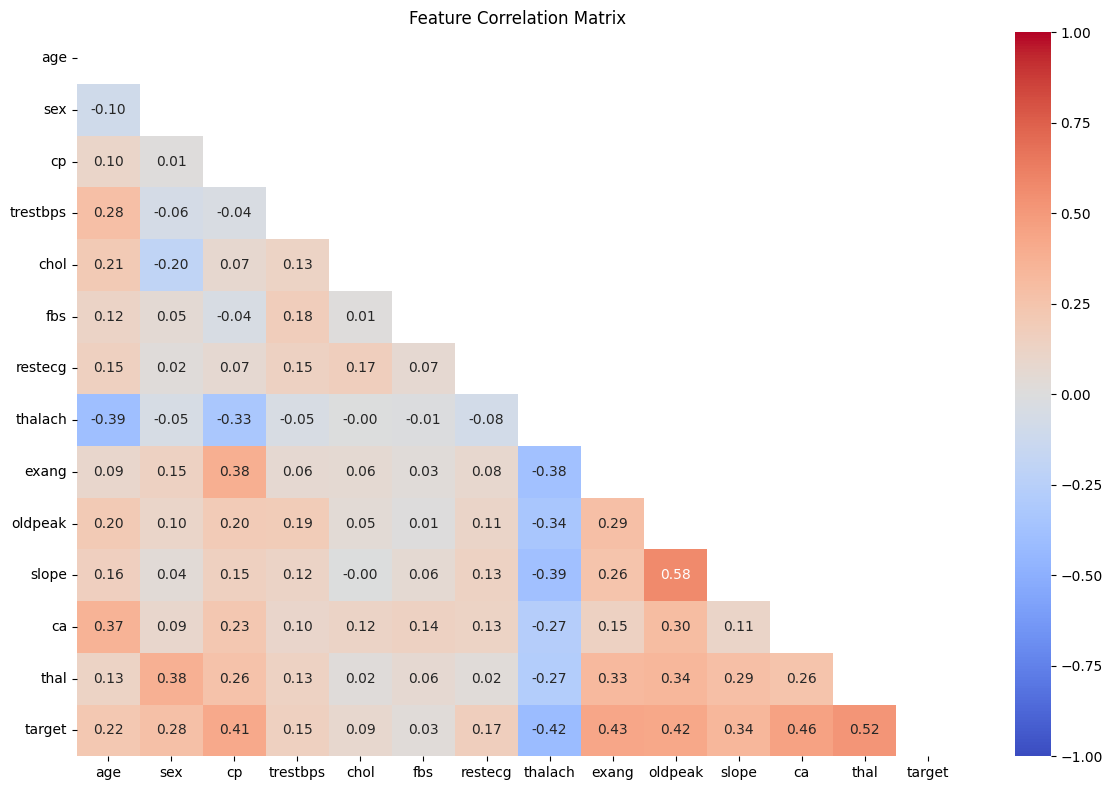

In [25]:
plt.figure(figsize=(12, 8))
# Creating a mask to hide the upper triangle for a cleaner look
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(
    df.corr(), annot=True, fmt=".2f", cmap="coolwarm", mask=mask, vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

C:\Users\Windows 11-Pro Edu\AppData\Local\Temp\ipykernel_2336\1104004845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="age", data=df, palette="Pastel1")


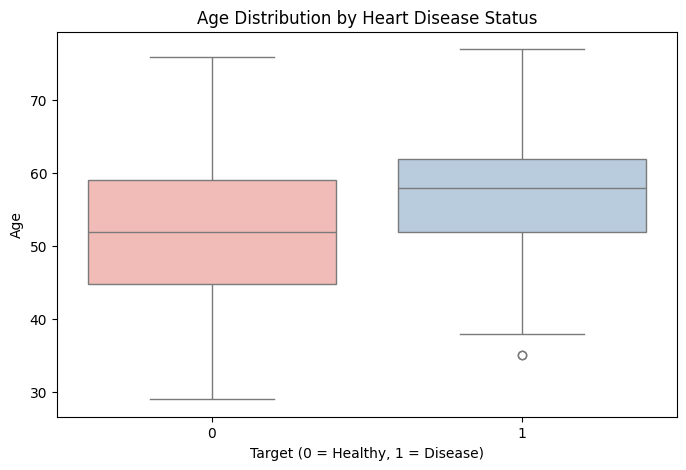

In [26]:
# Bonus: Age vs Target (to check your example observation)
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="age", data=df, palette="Pastel1")
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Target (0 = Healthy, 1 = Disease)")
plt.ylabel("Age")
plt.show()

# Hungarian

In [30]:
# Load the dataset
df2 = pd.read_csv("data/processed/hungarian_clean.csv")
df2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,0.0,6.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,0.0,6.0,0
2,29,1,2,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,0.0,6.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,0.0,6.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,0.0,6.0,0


In [31]:
df2["target"].value_counts()

target
0    188
1    106
Name: count, dtype: int64

In [32]:
df2.isnull().sum()

age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca            0
thal          0
target        0
dtype: int64